# Energy Price and Renewable Availability Scenarios

This notebook defines the energy inputs used before solving any Gurobi or QUBO scheduling instance.

Inputs:

- `MARGINALPDBC` files: day-ahead grid energy price by hour.
- PVGIS solar time series: hourly solar production for a 250 kWp PV system in Madrid.

Goal:

- build comparable 24-hour energy scenarios;
- inspect grid price and renewable availability together;
- define a placeholder renewable price;
- define and visualize the `effective_price[t]` approximation used by QUBO.

No scheduling problem is solved in this notebook.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.energy_prices import load_marginalpdbc
from src.data.scenarios import ENERGY_SCENARIOS
from src.data.solar_profiles import build_daily_hourly_solar_profile

PVGIS_PATH = PROJECT_ROOT / "data" / "energy" / "solar" / "Timeseries_40.409_-3.698_SA3_1000kWp_crystSi_14_36deg_-5deg_2020_2023.csv"
PRICE_COLUMN = "last"
BASE_SOLAR_CAPACITY_KWP = 250.0
TARGET_SOLAR_CAPACITY_KWP = None
PUE = 1.25
MIN_LOAD_FRACTION = 0.10


## 1. Scenario Inputs

The repo currently defines three energy scenarios. Each scenario has a calendar date and a matching day-ahead price file.

The solar CSV covers 2020-2023, so we extract the actual PVGIS solar profile for the same scenario date.


In [2]:
scenario_rows = []
for scenario_name, scenario in ENERGY_SCENARIOS.items():
    scenario_rows.append({
        "scenario": scenario_name,
        "date": scenario["date"],
        "month": scenario["month"],
        "price_file": str(PROJECT_ROOT / scenario["price_file"]),
    })
scenario_table = pd.DataFrame(scenario_rows).sort_values("date", ignore_index=True)
scenario_table


,scenario,date,month,price_file
0,clear_sky,2023-04-04,4,/Users/juanparrado/Documents/Quantum Master/ma...
1,overcast,2023-06-07,6,/Users/juanparrado/Documents/Quantum Master/ma...
2,base,2023-09-27,9,/Users/juanparrado/Documents/Quantum Master/ma...


## 2. Build Hourly Energy Tables

For each scenario we build a 24-row table with:

```text
hour
grid_price              day-ahead marginal price
renewable_available     PVGIS solar production in MW
renewable_price         placeholder renewable price
```

Placeholder rule:

```text
renewable_price = 0.8 * min(grid_price for that day)
```

This guarantees renewable energy is cheaper than grid energy inside each scenario. We can replace it later with an LCOE, PPA price, or opportunity-cost assumption.


In [3]:
def build_energy_scenario_table(scenario_name: str, scenario: dict) -> pd.DataFrame:
    """Combine one MARGINALPDBC price day with same-day PVGIS solar production."""

    price_path = PROJECT_ROOT / scenario["price_file"]
    price_df = load_marginalpdbc(price_path, price_column=PRICE_COLUMN)
    solar_df = build_daily_hourly_solar_profile(
        PVGIS_PATH,
        scenario["date"],
        base_capacity_kwp=BASE_SOLAR_CAPACITY_KWP,
        target_capacity_kwp=TARGET_SOLAR_CAPACITY_KWP,
    )
    hourly = price_df[["hour", "grid_price", "price_1", "price_2"]].merge(
        solar_df[["hour", "renewable_available"]],
        on="hour",
        how="inner",
        validate="one_to_one",
    )
    if len(hourly) != 24:
        raise ValueError(f"scenario {scenario_name} produced {len(hourly)} hourly rows")
    renewable_price = 0.8 * float(hourly["grid_price"].min())
    hourly["renewable_price"] = renewable_price
    hourly["scenario"] = scenario_name
    hourly["date"] = scenario["date"]
    hourly["pue"] = PUE
    return hourly[[
        "scenario", "date", "hour", "grid_price", "renewable_available", "renewable_price", "pue", "price_1", "price_2"
    ]]

energy_tables = {
    name: build_energy_scenario_table(name, scenario)
    for name, scenario in ENERGY_SCENARIOS.items()
}
energy_df = pd.concat(energy_tables.values(), ignore_index=True)
energy_df.head(10)


,scenario,date,hour,grid_price,renewable_available,renewable_price,pue,price_1,price_2
0,clear_sky,2023-04-04,0,92.18,0.000000,6.4,1.25,92.18,92.18
1,clear_sky,2023-04-04,1,68.25,0.000000,6.4,1.25,68.25,68.25
2,clear_sky,2023-04-04,2,85.00,0.000000,6.4,1.25,85.00,85.00
3,clear_sky,2023-04-04,3,79.21,0.000000,6.4,1.25,79.21,79.21
4,clear_sky,2023-04-04,4,65.27,0.000000,6.4,1.25,65.27,65.27
5,clear_sky,2023-04-04,5,65.50,0.000000,6.4,1.25,65.50,65.50
6,clear_sky,2023-04-04,6,76.24,0.000043,6.4,1.25,76.24,76.24
7,clear_sky,2023-04-04,7,89.65,0.035373,6.4,1.25,89.65,89.65
8,clear_sky,2023-04-04,8,90.99,0.097988,6.4,1.25,90.99,90.99
9,clear_sky,2023-04-04,9,59.00,0.151732,6.4,1.25,59.00,59.00


In [4]:
energy_summary = (
    energy_df
    .groupby(["scenario", "date"])
    .agg(
        min_grid_price=("grid_price", "min"),
        mean_grid_price=("grid_price", "mean"),
        max_grid_price=("grid_price", "max"),
        grid_price_std=("grid_price", "std"),
        renewable_price=("renewable_price", "first"),
        total_renewable_mwh=("renewable_available", "sum"),
        max_renewable_mw=("renewable_available", "max"),
        solar_hours=("renewable_available", lambda values: int((values > 0).sum())),
    )
    .reset_index()
    .sort_values("date")
)
energy_summary.round(4)


,scenario,date,min_grid_price,mean_grid_price,max_grid_price,grid_price_std,renewable_price,total_renewable_mwh,max_renewable_mw,solar_hours
1,clear_sky,2023-04-04,8.00,56.2054,106.14,34.7741,6.400,1.6408,0.2230,13
2,overcast,2023-06-07,65.70,87.1600,107.36,11.8578,52.560,0.2598,0.0509,15
0,base,2023-09-27,77.14,114.8346,170.00,24.8729,61.712,1.2820,0.1788,11


## 3. Grid Price Profiles

These plots compare the hourly day-ahead price curves for the three candidate days.


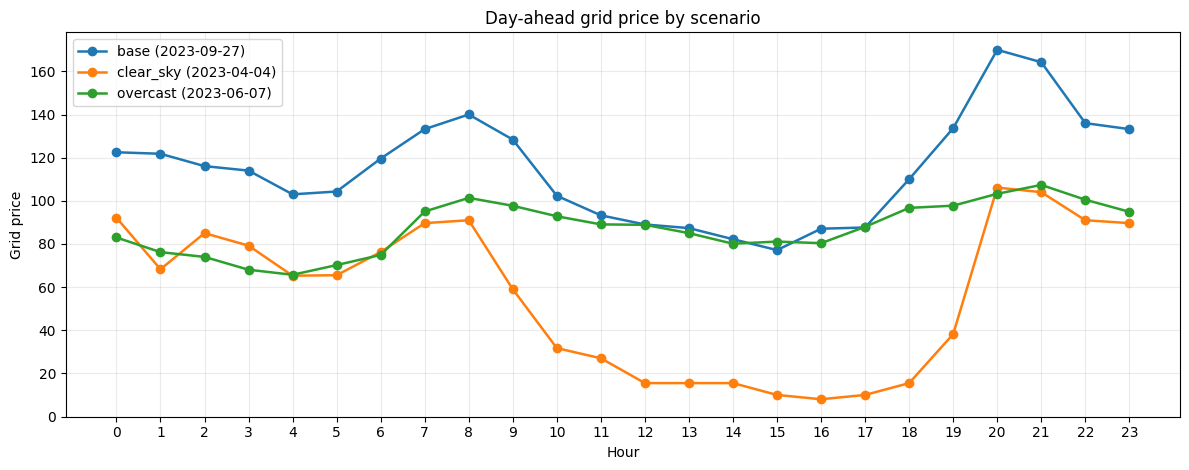

In [5]:
fig, ax = plt.subplots(figsize=(12, 4.8))
for scenario, group in energy_df.groupby("scenario"):
    ax.plot(group["hour"], group["grid_price"], marker="o", linewidth=1.8, label=f"{scenario} ({group['date'].iloc[0]})")
ax.set_title("Day-ahead grid price by scenario")
ax.set_xlabel("Hour")
ax.set_ylabel("Grid price")
ax.set_xticks(range(24))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## 4. Solar Production Profiles

`renewable_available` is computed from the PVGIS `P` column:

```text
renewable_available[t] = P[t] / 1,000,000
```

The source PV system is 250 kWp. If the thesis scenario uses a different solar capacity, we can pass `target_capacity_kwp` and scale the profile.


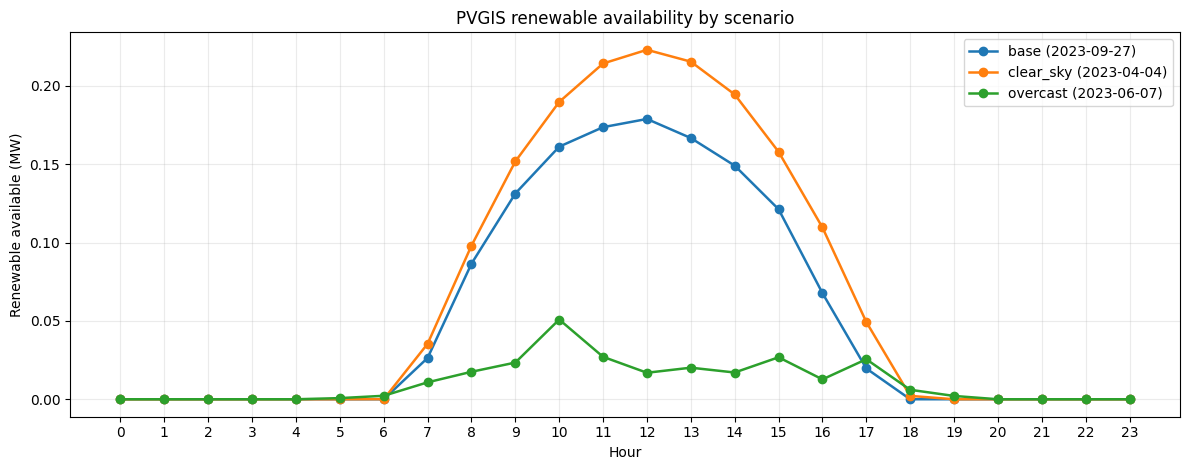

In [6]:
fig, ax = plt.subplots(figsize=(12, 4.8))
for scenario, group in energy_df.groupby("scenario"):
    ax.plot(group["hour"], group["renewable_available"], marker="o", linewidth=1.8, label=f"{scenario} ({group['date'].iloc[0]})")
ax.set_title("PVGIS renewable availability by scenario")
ax.set_xlabel("Hour")
ax.set_ylabel("Renewable available (MW)")
ax.set_xticks(range(24))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## 5. Grid Price and Solar Together

This view helps identify whether cheap/expensive grid hours coincide with renewable availability.

For scheduling, the strongest shift incentive usually appears when high renewable availability overlaps expensive grid hours, or when renewable availability creates a low effective price during otherwise normal grid-price periods.


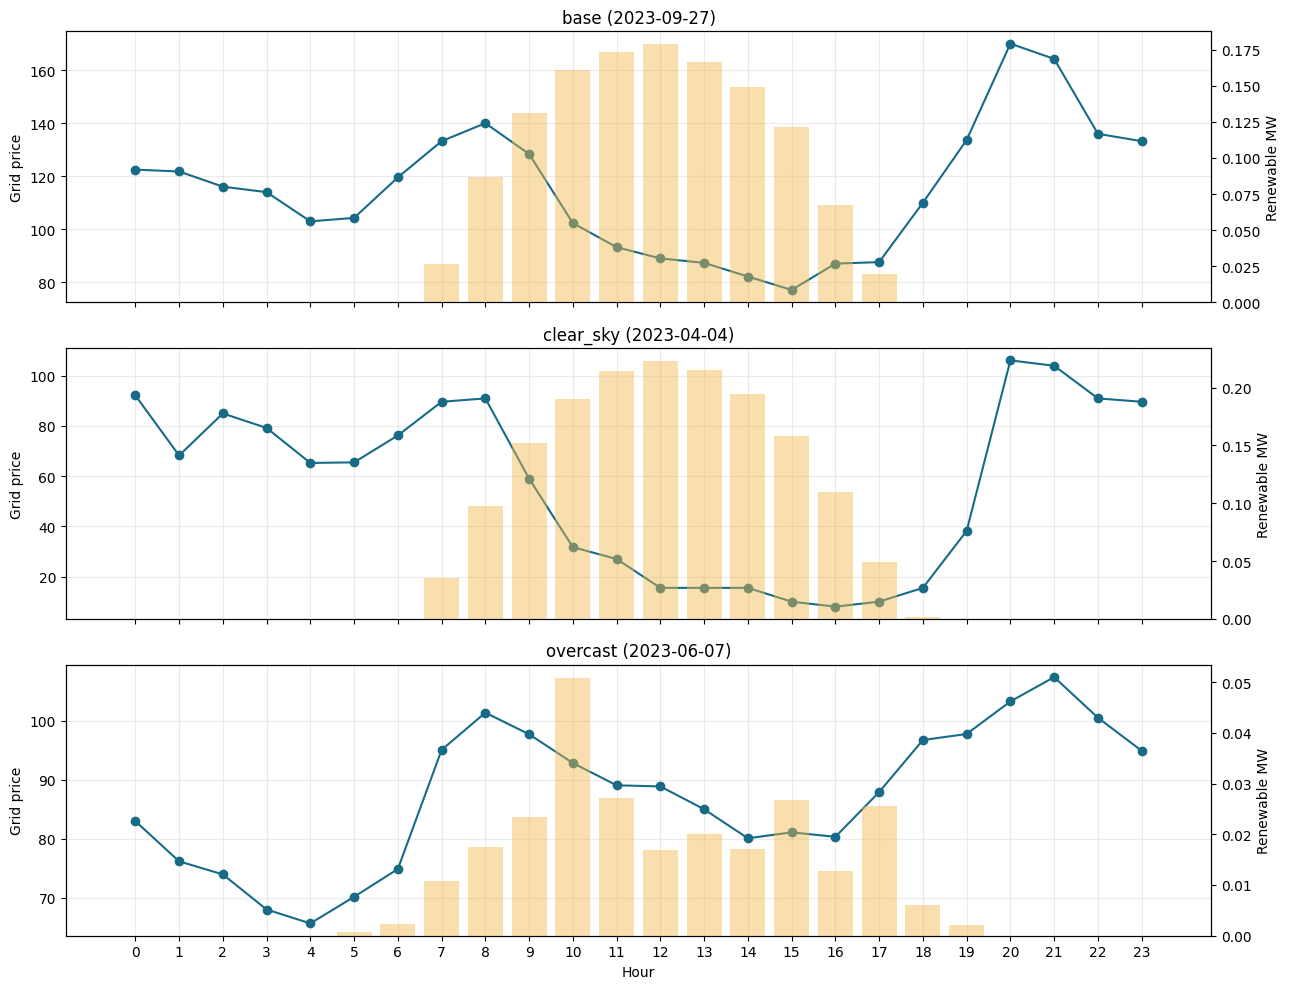

In [7]:
fig, axes = plt.subplots(len(ENERGY_SCENARIOS), 1, figsize=(13, 10), sharex=True)
for ax, (scenario, group) in zip(axes, energy_df.groupby("scenario")):
    ax2 = ax.twinx()
    ax.plot(group["hour"], group["grid_price"], color="#176b87", marker="o", label="grid price")
    ax2.bar(group["hour"], group["renewable_available"], color="#f2b84b", alpha=0.45, label="renewable available")
    ax.set_title(f"{scenario} ({group['date'].iloc[0]})")
    ax.set_ylabel("Grid price")
    ax2.set_ylabel("Renewable MW")
    ax.grid(alpha=0.25)
axes[-1].set_xlabel("Hour")
axes[-1].set_xticks(range(24))
plt.tight_layout()
plt.show()


## 6. Effective Price for QUBO

Gurobi can keep `grid_price[t]` and `renewable_available[t]` separate because it has continuous variables for renewable and grid usage.

The reduced QUBO does not include continuous dispatch variables, so it needs a scalar price coefficient per hour. We approximate this with:

```text
renewable_share[t] = min(1, renewable_available[t] / expected_load_scale)

effective_price[t] = renewable_share[t] * renewable_price
                   + (1 - renewable_share[t]) * grid_price[t]
```

For a real scheduling instance, we compute:

```text
expected_load_scale(instance) = max(
    PUE * sum_i(power_i * duration_i) / T,
    min_load_fraction * cluster_it_capacity_mw * PUE
)
```

This notebook does not yet load job instances. Instead, it visualizes the function for several example load scales.


In [8]:
def effective_price_profile(
    hourly_df: pd.DataFrame,
    expected_load_scale_mw: float,
) -> pd.DataFrame:
    """Compute QUBO effective price for a chosen expected load scale."""

    if expected_load_scale_mw <= 0:
        raise ValueError("expected_load_scale_mw must be positive")
    out = hourly_df.copy()
    out["renewable_share"] = (out["renewable_available"] / expected_load_scale_mw).clip(lower=0.0, upper=1.0)
    out["effective_price"] = (
        out["renewable_share"] * out["renewable_price"]
        + (1.0 - out["renewable_share"]) * out["grid_price"]
    )
    out["expected_load_scale_mw"] = expected_load_scale_mw
    return out

example_load_scales_mw = [0.05, 0.10, 0.25, 0.50, 1.00]

effective_examples = []
for _, group in energy_df.groupby("scenario"):
    for load_scale in example_load_scales_mw:
        effective_examples.append(effective_price_profile(group, load_scale))
effective_df = pd.concat(effective_examples, ignore_index=True)
effective_df.head()


,scenario,date,hour,grid_price,renewable_available,renewable_price,pue,price_1,price_2,renewable_share,effective_price,expected_load_scale_mw
0,base,2023-09-27,0,122.50,0.0,61.712,1.25,122.50,122.50,0.0,122.50,0.05
1,base,2023-09-27,1,121.80,0.0,61.712,1.25,121.80,121.80,0.0,121.80,0.05
2,base,2023-09-27,2,116.08,0.0,61.712,1.25,116.08,116.08,0.0,116.08,0.05
3,base,2023-09-27,3,114.00,0.0,61.712,1.25,114.00,114.00,0.0,114.00,0.05
4,base,2023-09-27,4,103.00,0.0,61.712,1.25,103.00,103.00,0.0,103.00,0.05


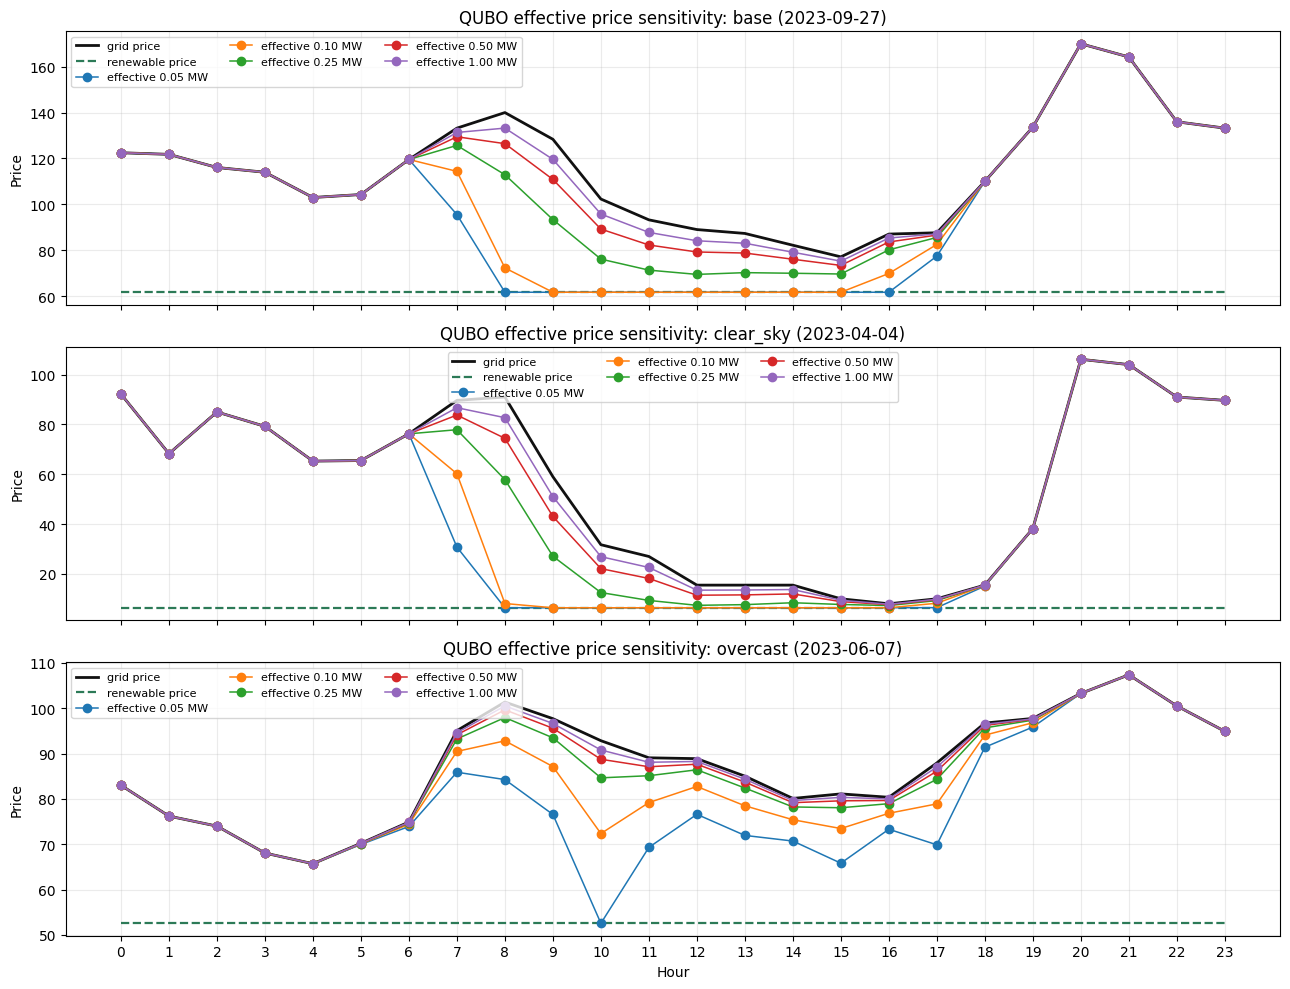

In [9]:
fig, axes = plt.subplots(len(ENERGY_SCENARIOS), 1, figsize=(13, 10), sharex=True)
for ax, (scenario, scenario_effective) in zip(axes, effective_df.groupby("scenario")):
    base = energy_df[energy_df["scenario"] == scenario]
    ax.plot(base["hour"], base["grid_price"], color="#111111", linewidth=2.0, label="grid price")
    ax.plot(base["hour"], base["renewable_price"], color="#2c7a57", linestyle="--", linewidth=1.6, label="renewable price")
    for load_scale, group in scenario_effective.groupby("expected_load_scale_mw"):
        ax.plot(group["hour"], group["effective_price"], marker="o", linewidth=1.1, label=f"effective {load_scale:.2f} MW")
    ax.set_title(f"QUBO effective price sensitivity: {scenario} ({base['date'].iloc[0]})")
    ax.set_ylabel("Price")
    ax.grid(alpha=0.25)
    ax.legend(ncol=3, fontsize=8)
axes[-1].set_xlabel("Hour")
axes[-1].set_xticks(range(24))
plt.tight_layout()
plt.show()


## 7. Candidate Scenario Tables for Scheduling

The tables below are model-ready energy inputs before instance-specific QUBO effective prices.

For Gurobi, use:

```text
hour, renewable_available, grid_price, pue
```

For QUBO, use the same table plus an instance-specific `effective_price[t]` computed after loading the jobs and cluster.


In [10]:
model_ready_energy_tables = {
    scenario: group[["hour", "renewable_available", "grid_price", "pue", "renewable_price"]].reset_index(drop=True)
    for scenario, group in energy_df.groupby("scenario")
}

for scenario, table in model_ready_energy_tables.items():
    print(f"\n{scenario}")
    print(table.head(24).to_string(index=False))



base
 hour  renewable_available  grid_price  pue  renewable_price
    0             0.000000      122.50 1.25           61.712
    1             0.000000      121.80 1.25           61.712
    2             0.000000      116.08 1.25           61.712
    3             0.000000      114.00 1.25           61.712
    4             0.000000      103.00 1.25           61.712
    5             0.000000      104.30 1.25           61.712
    6             0.000000      119.57 1.25           61.712
    7             0.026345      133.23 1.25           61.712
    8             0.086468      140.01 1.25           61.712
    9             0.131272      128.37 1.25           61.712
   10             0.161145      102.33 1.25           61.712
   11             0.173597       93.26 1.25           61.712
   12             0.178825       89.03 1.25           61.712
   13             0.166665       87.34 1.25           61.712
   14             0.149042       82.20 1.25           61.712
   15             

## 8. Notes for the Scheduling Notebooks

The scheduling notebooks should stop using synthetic prices such as `55/70/90` and instead select one of these scenario tables.

Suggested next steps:

1. Choose which energy scenario to use first for `tiny_6_jobs`.
2. Feed `grid_price` and `renewable_available` directly into Gurobi.
3. Compute `expected_load_scale(instance)` after loading each job instance.
4. Compute `effective_price[t]` for QUBO from the selected energy scenario.
5. Compare Gurobi and QUBO only after both use the same underlying energy day.
